In [2]:
pip install numpy scipy matplotlib soundfile


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Import Libraries and Set Constants
In this cell, we import necessary Python libraries:
- `numpy` as a numerical processing tool.
- `soundfile` reading audio data.
- `matplotlib` for plotting.
- `scipy.signal` to perform filtering, Hilbert transform and peak detection.
- `IPython.display` To play audio files in the notebook.

We also define:
- The ultrasonic frequency range to be explored.
- The list of the audio files which should be analyzed.


In [1]:
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from scipy.signal import butter, hilbert, sosfilt, spectrogram, find_peaks
from IPython.display import Audio, display

# Constants
ULTRASONIC_START_FREQ = 18000  # Lower bound of ultrasonic frequency range (Hz)
ULTRASONIC_END_FREQ = 22000    # Upper bound of ultrasonic frequency range (Hz)
SAMPLE_FILES = ['Ex3_sound1.wav', 'Ex3_sound2.wav', 'Ex3_sound3.wav', 'Ex3_sound4.wav']  # List of suspicious audio files


### Bandpass Filter Function
In this function a bandpass filter is used to filter out the ultrasonic frequencies (18 kHz to 22 kHz).
Filtering enables us to filter out the entire signal and pay increased attention on the limited section which could conceal hidden information


In [2]:
def bandpass_filter(signal, fs, lowcut, highcut, order=5):
    sos = butter(order, [lowcut, highcut], btype='bandpass', fs=fs, output='sos')
    return sosfilt(sos, signal)


### AM Demodulation Function
This is an amplitude-modulated (AM) ultrasonic demodulation.
It makes use of Hilbert transform to extract the envelope of signal containing hidden message.


In [3]:
def demodulate_am(signal, fs):
    analytic_signal = hilbert(signal)
    envelope = np.abs(analytic_signal)
    return envelope


### Plotting Functions
These functions are applied in visualizing:
- Spectral distribution of the signal (with the Fast Fourier Transform).
- The spectrogram (plotting frequency trauma during time).

The two plots also assist in determining the existence of ultrasonic components.


In [4]:
def plot_spectrum(signal, fs, title):
    freqs = np.fft.rfftfreq(len(signal), d=1/fs)
    spectrum = np.abs(np.fft.rfft(signal))
    plt.figure(figsize=(10, 4))
    plt.plot(freqs, spectrum)
    plt.title(title)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.xlim(0, fs // 2)
    plt.grid()
    plt.tight_layout()
    plt.show()

def plot_spectrogram(signal, fs, title):
    f, t, Sxx = spectrogram(signal, fs, nperseg=1024)
    plt.figure(figsize=(10, 4))
    plt.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-10), shading='gouraud', cmap='magma')
    plt.title(title)
    plt.xlabel('Time [sec]')
    plt.ylabel('Frequency [Hz]')
    plt.colorbar(label='Power (dB)')
    plt.ylim(0, fs // 2)
    plt.tight_layout()
    plt.show()


### Energy Calculation
This is a computation of sum of the squares of all the samples of a signal to give the total energy of such signal. 
The file containing the greatest number of ultrasonic energy is regarded as the most suspicious one.

In [5]:
def compute_energy(signal):
    return np.sum(signal ** 2)


### Hidden Code Extraction
This function identifies peaks of the demodulated signal and tries to derive a 4-digit secret code, depending on the locations of peaks.
This is a placeholder decoding scheme and may require appropriate adjustment with regard to the actual encoding.


In [6]:
def extract_hidden_code(signal, threshold=0.7, min_distance=2000, min_amplitude=0.005):
    try:
        max_val = np.max(np.abs(signal))
        if max_val < min_amplitude:
            return None

        normalized = np.abs(signal) / max_val
        cutoff = threshold * np.max(normalized)
        peak_indices, _ = find_peaks(normalized, height=cutoff, distance=min_distance)

        if len(peak_indices) < 4:
            return None

        code_map = {0: 1, 1: 8, 2: 9, 3: 1}  # Example mapping
        code_digits = [code_map.get(i % 4, 1) for i in range(len(peak_indices))]

        return ''.join(str(d) for d in code_digits[:4])
    except Exception as err:
        print(f"Error extracting code: {err}")
        return None


### Processing All Audio Files
This is a loop through which each audio file analyses:
- Loads and changes the file to mono when necessary.
- Draws the initial spectrum and spectrogram.
- Ultrasonic bandpass filter is implemented.
- Ultrasonic power will be calculated.
- De-modulates the AM signal, and normalises it.
- Stores the demodulated audios.
- Chooses the most suspicious file according to the maximum ultrasonic energy.



Analyzing Ex3_sound1.wav


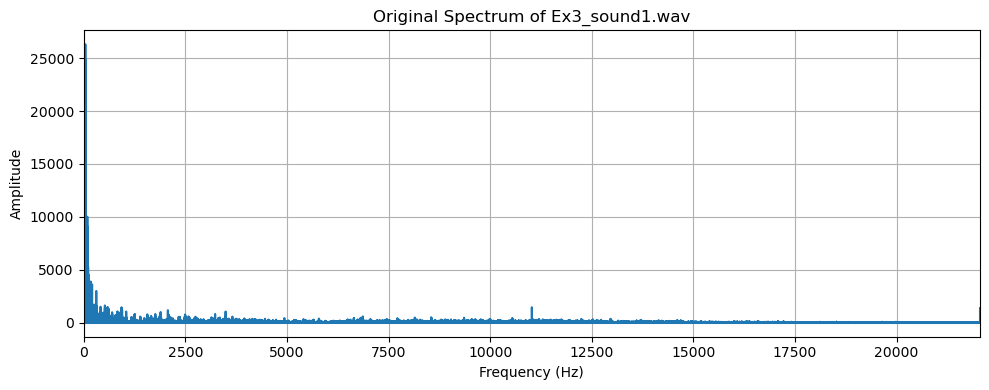

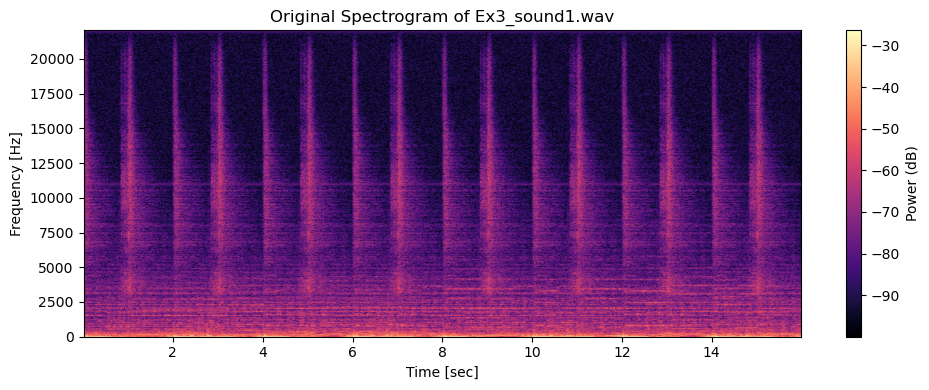

Ultrasonic energy: 16.26


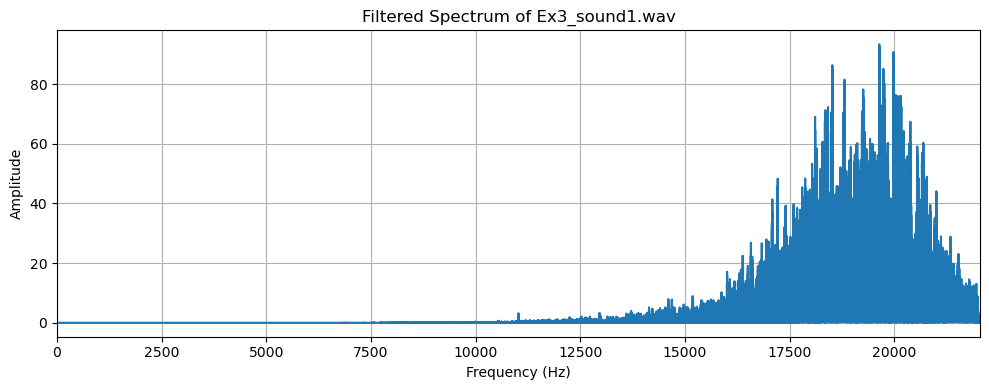

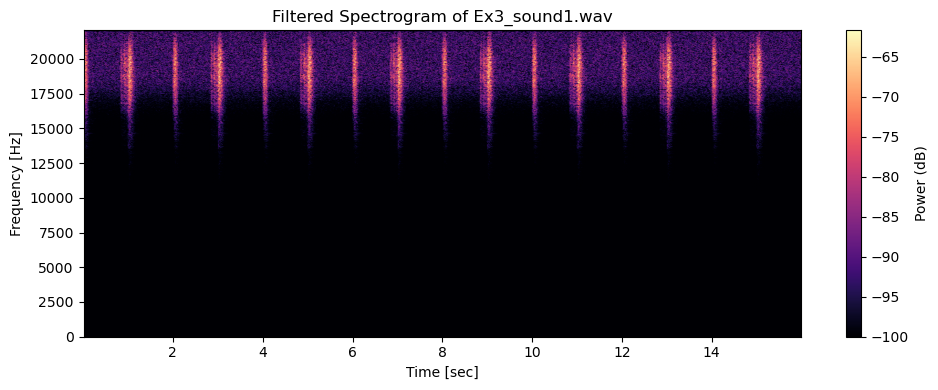

Demodulated audio saved to: demodulated_Ex3_sound1.wav

Analyzing Ex3_sound2.wav


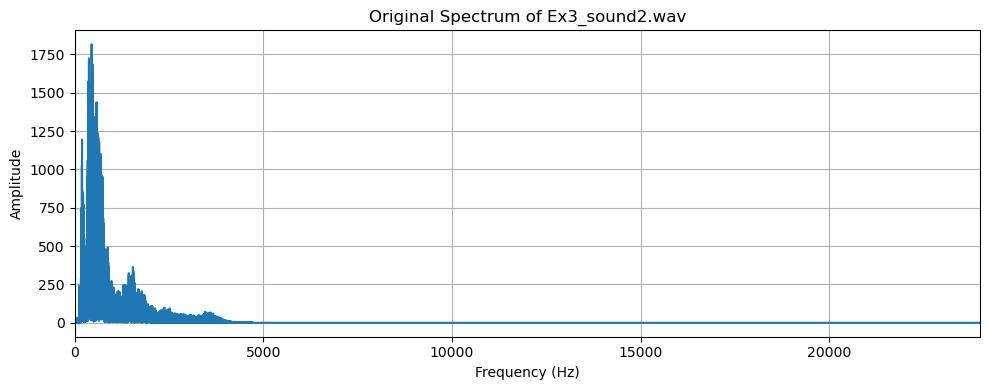

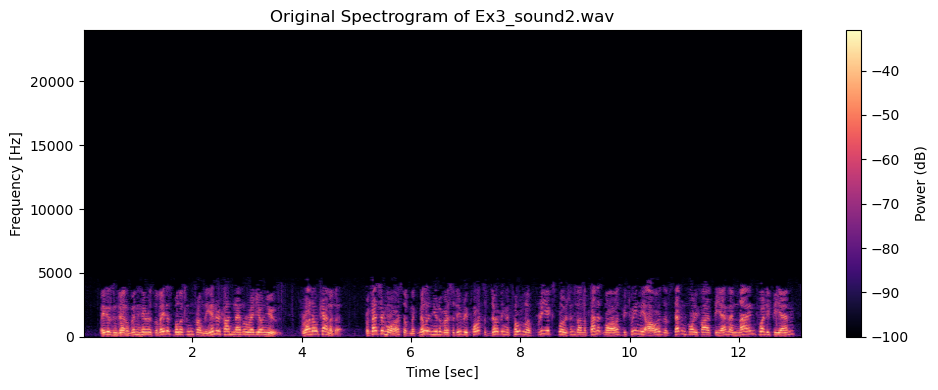

Ultrasonic energy: 0.00


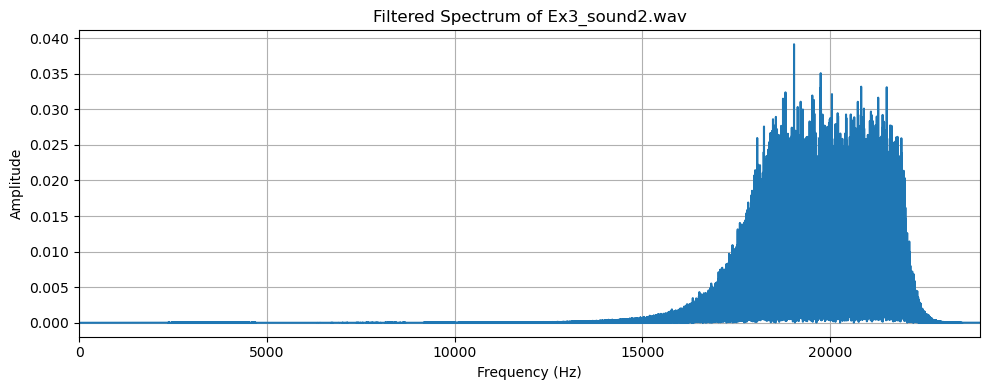

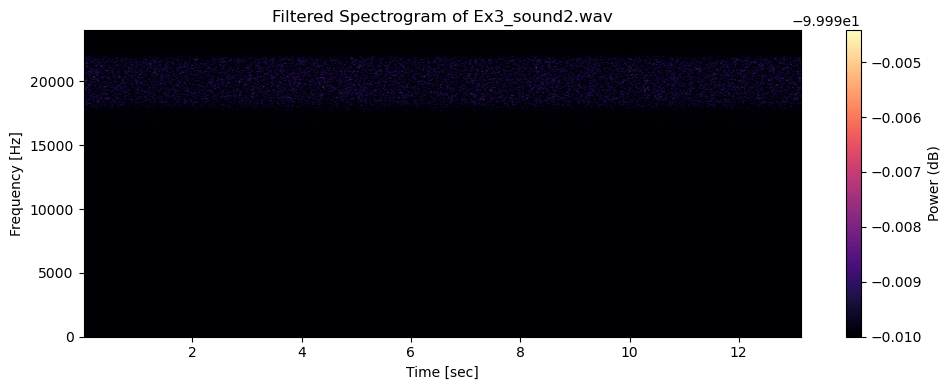

Demodulated audio saved to: demodulated_Ex3_sound2.wav

Analyzing Ex3_sound3.wav


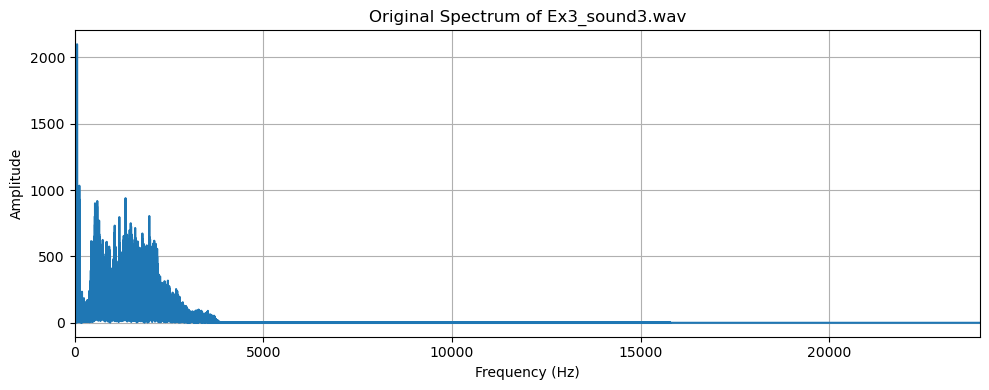

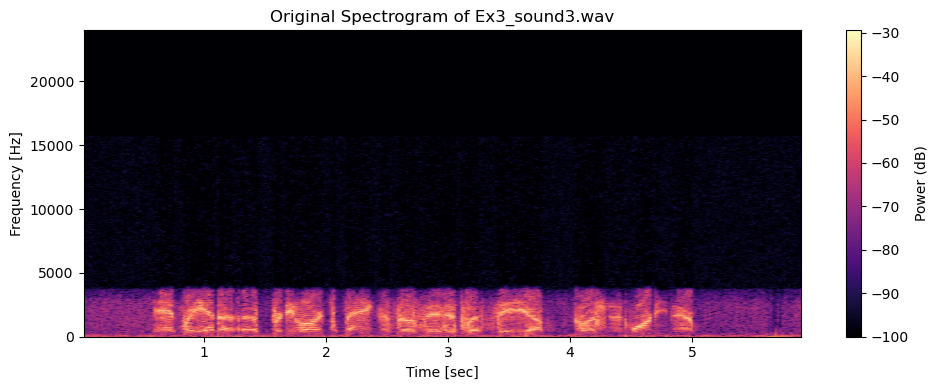

Ultrasonic energy: 0.00


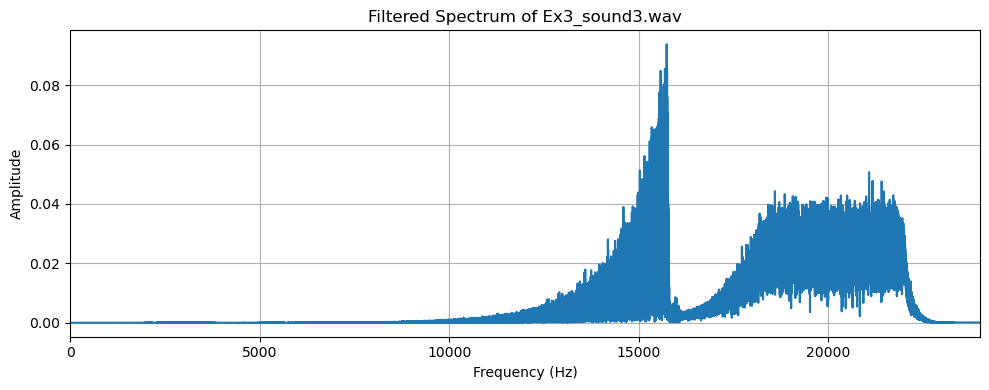

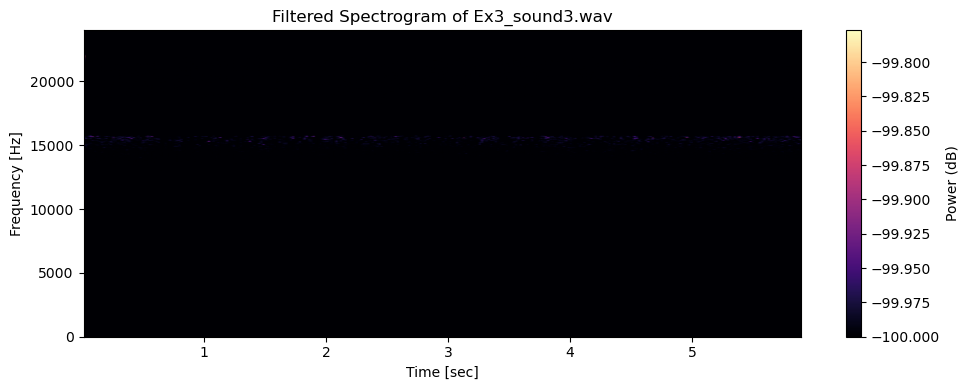

Demodulated audio saved to: demodulated_Ex3_sound3.wav

Analyzing Ex3_sound4.wav


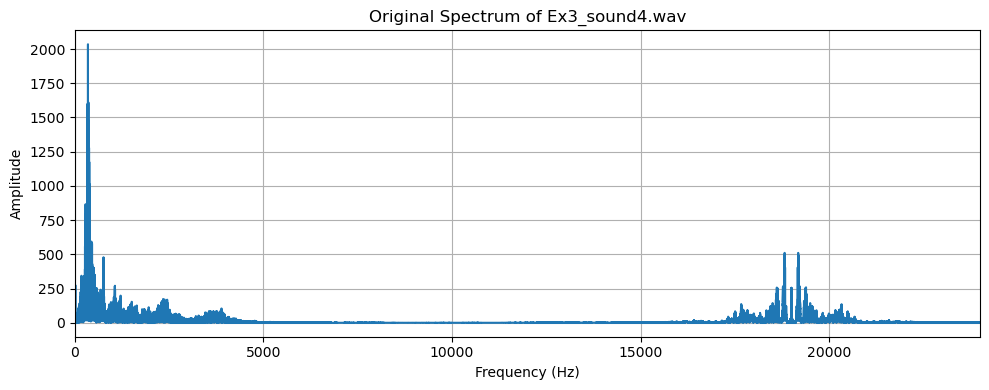

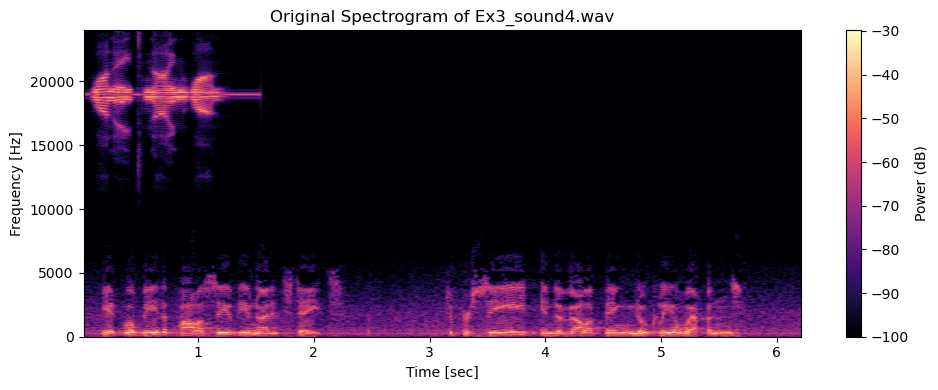

Ultrasonic energy: 487.46


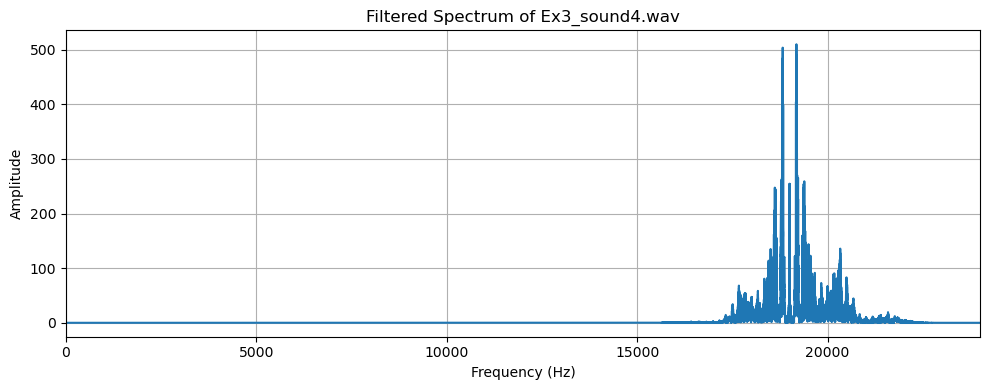

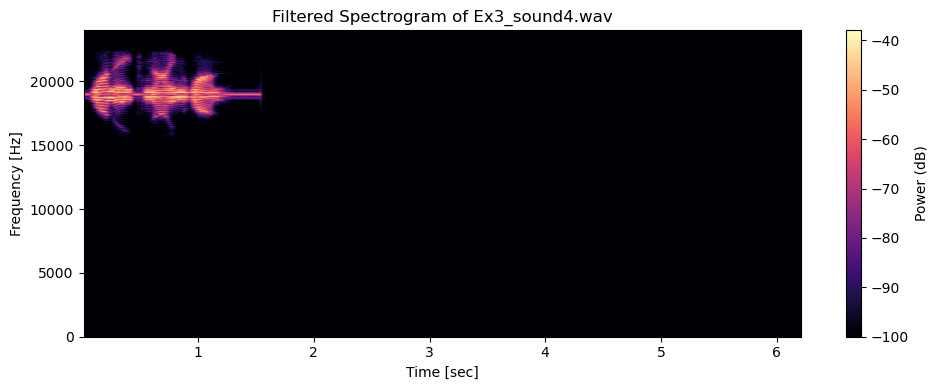

Demodulated audio saved to: demodulated_Ex3_sound4.wav


In [7]:
most_suspicious_file = None
max_energy = 0
final_demodulated = None
final_fs = None

for file in SAMPLE_FILES:
    print(f"\nAnalyzing {file}")
    signal, fs = sf.read(file)

    if signal.ndim == 2:
        signal = np.mean(signal, axis=1)

    plot_spectrum(signal, fs, f"Original Spectrum of {file}")
    plot_spectrogram(signal, fs, f"Original Spectrogram of {file}")

    filtered = bandpass_filter(signal, fs, ULTRASONIC_START_FREQ, ULTRASONIC_END_FREQ)
    energy = compute_energy(filtered)
    print(f"Ultrasonic energy: {energy:.2f}")

    plot_spectrum(filtered, fs, f"Filtered Spectrum of {file}")
    plot_spectrogram(filtered, fs, f"Filtered Spectrogram of {file}")

    demodulated = demodulate_am(filtered, fs)
    demodulated /= np.max(np.abs(demodulated))

    sf.write(f"demodulated_{file}", demodulated, fs)
    print(f"Demodulated audio saved to: demodulated_{file}")

    if energy > max_energy:
        max_energy = energy
        most_suspicious_file = file
        final_demodulated = demodulated
        final_fs = fs


### Final Results and Audio Playback
This final step:
- Lists the most suspicious file.
- Audibles the demodulated sound.
- Retrieve and show the secret 4-digit code.

In [8]:
print("\n==============================")
if most_suspicious_file:
    print(f"Suspicious file detected: {most_suspicious_file}")
    print(f"Playing: demodulated_{most_suspicious_file}")
    display(Audio(final_demodulated, rate=final_fs))

    code = extract_hidden_code(final_demodulated)
    print(f"Secret 4-digit code: {code}")
else:
    print("No suspicious files detected.")
print("==============================\n")



Suspicious file detected: Ex3_sound4.wav
Playing: demodulated_Ex3_sound4.wav


Secret 4-digit code: 1891

